# Projet Serie Temporelle

![Nile River](img/Nile-River.jpg)

## Analyse du débit annuel du Nil

Étude et modélisation d’une série temporelle réelle à partir du dataset Nile.

## Contexte

Le Nil est l’un des fleuves les plus importants au monde, jouant un rôle essentiel dans le développement de l’Égypte.

Le dataset **Nile**, disponible en R.

L’analyse de cette série temporelle permet de mieux comprendre :
- les variations du débit au fil du temps
- les changements structurels
- les tendances à long terme

## Objectifs

L’objectif de ce projet est d’exploiter la série temporelle du Nil afin de :

- Analyser son comportement (tendance, variabilité)
- Étudier les dépendances temporelles (ACF, PACF)
- Vérifier la stationnarité
- Appliquer des transformations si nécessaire (log, différenciation)
- Construire des modèles de prévision (ARIMA, lissage exponentiel, régression)
- Évaluer les performances des modèles

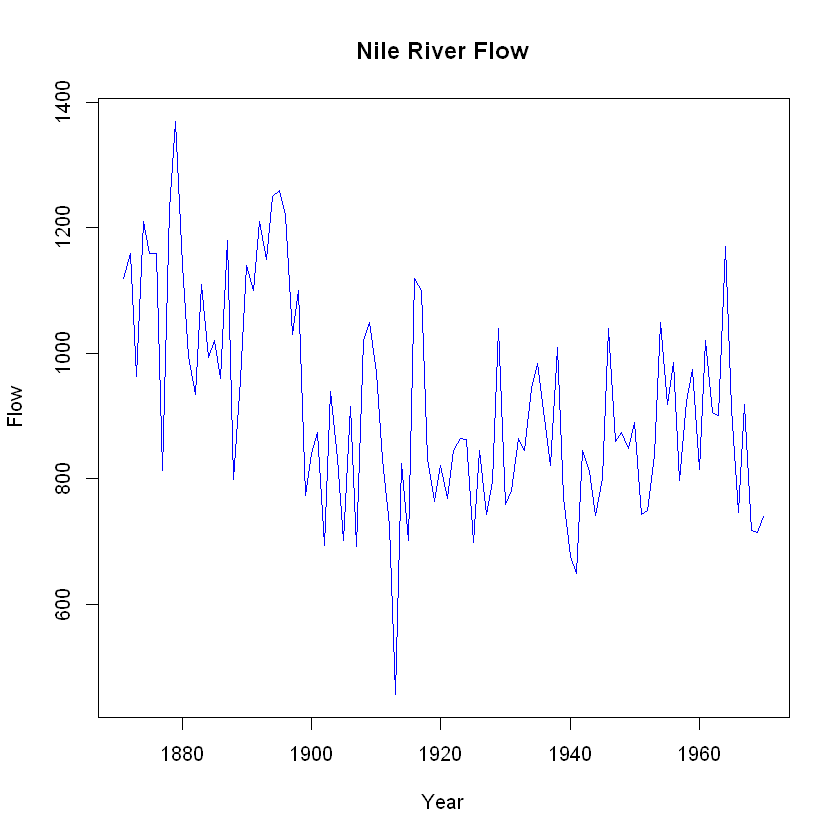

In [1]:
# Charger le dataset Nile
data(Nile)

# Afficher le graphique
plot(Nile,
     main = "Nile River Flow",
     ylab = "Flow",
     xlab = "Year",
     col = "blue",
     type = "l")

In [2]:
start(Nile)   # début
end(Nile)     # fin
frequency(Nile)  # fréquence

[1] 1871    1

[1] 1970    1

[1] 1

On peut observer que l’étude de cette série temporelle s’étend de 1871 à 1970.

La fréquence est égale à 1, ce qui signifie que les données sont annuelles.

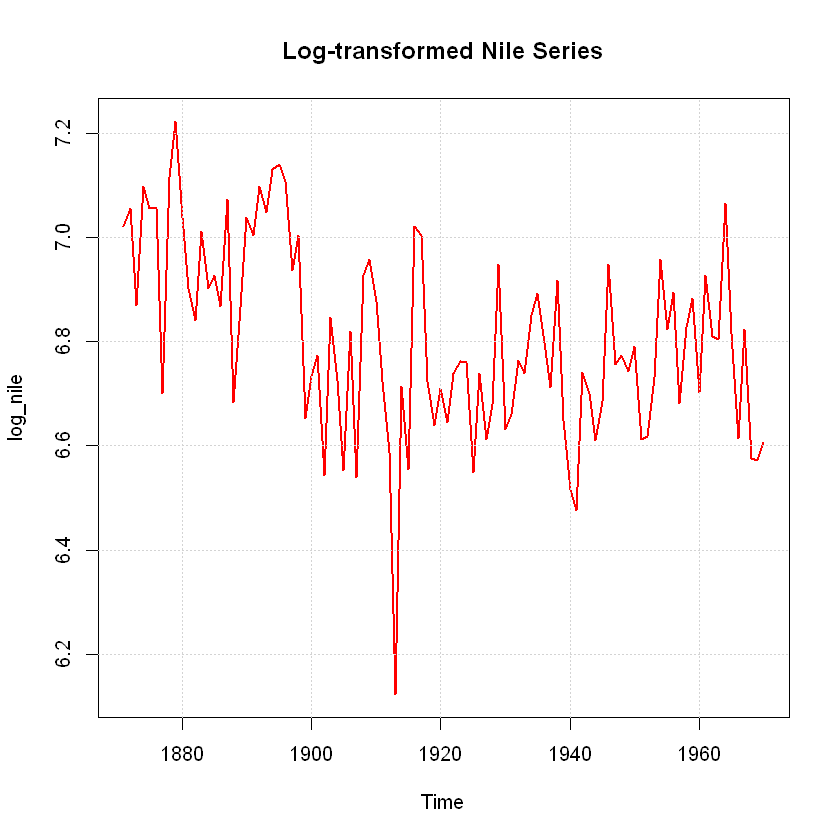

In [3]:
log_nile <- log(Nile)

plot(log_nile,
     main = "Log-transformed Nile Series",
     col = "red",
     lwd = 2)
grid()

In [4]:
help(Nile)

Nile                 package:datasets                  R Documentation

_F_l_o_w _o_f _t_h_e _R_i_v_e_r _N_i_l_e

_D_e_s_c_r_i_p_t_i_o_n:

     Measurements of the annual flow of the river Nile at Aswan
     (formerly 'Assuan'), 1871-1970, in 10^8 m^3, "with apparent
     changepoint near 1898" (Cobb(1978), Table 1, p.249).

_U_s_a_g_e:

     Nile
     
_F_o_r_m_a_t:

     A time series of length 100.

_S_o_u_r_c_e:

     Durbin, J. and Koopman, S. J. (2001).  _Time Series Analysis by
     State Space Methods_.  Oxford University Press.

_R_e_f_e_r_e_n_c_e_s:

     Balke, N. S. (1993).  Detecting level shifts in time series.
     _Journal of Business and Economic Statistics_, *11*, 81-92.
     doi:10.2307/1391308 <https://doi.org/10.2307/1391308>.

     Cobb, G. W. (1978).  The problem of the Nile: conditional solution
     to a change-point problem.  _Biometrika_ *65*, 243-51.
     doi:10.2307/2335202 <https://doi.org/10.2307/233

marcus : lissage exponentiel

flavio : arima

dhia : sarima

In [5]:
# check saisonality
plot(decompose(data))


ERROR: Error in decompose(data): la série temporelle a moins de 2 périodes


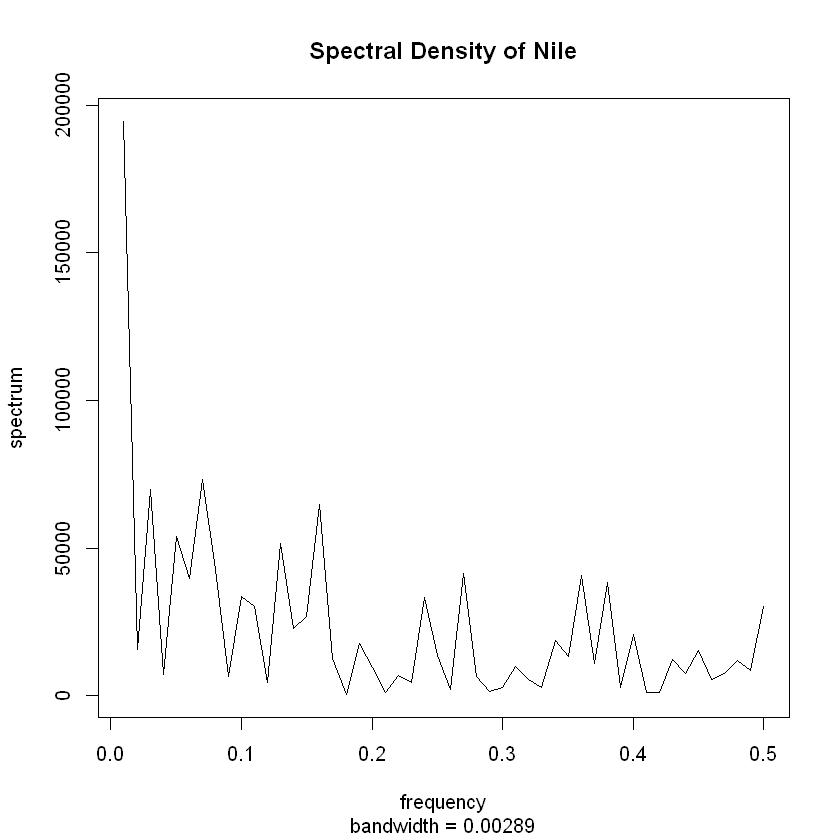

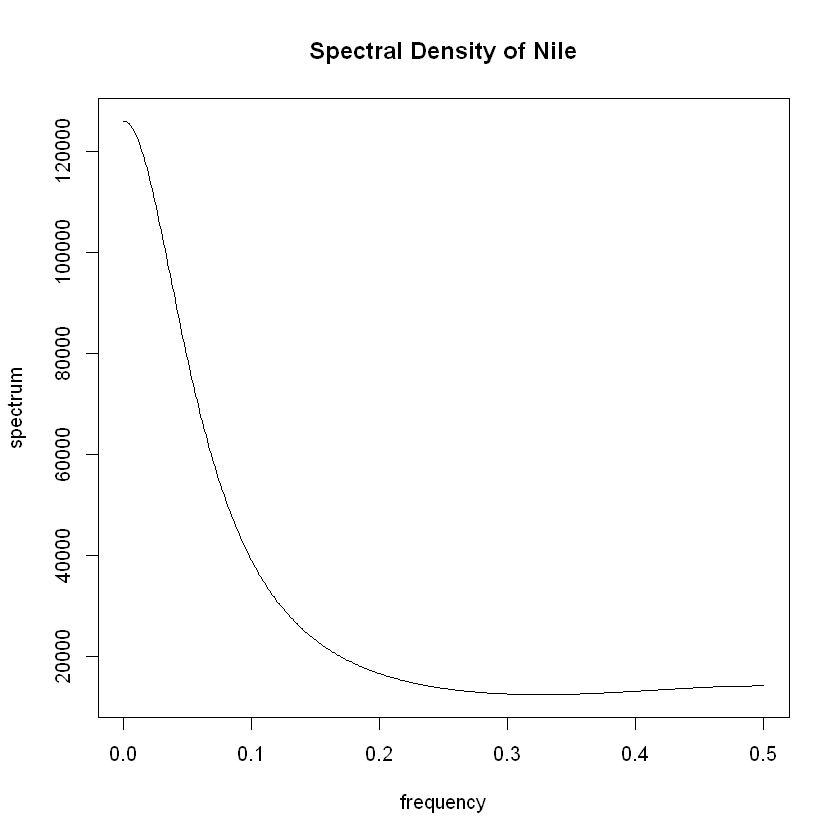

In [ ]:
# densité spectrale
spectrum(Nile, log = "no", main = "Spectral Density of Nile")

# densité spectrale AR(2)
spectrum(Nile, log = "no", main = "Spectral Density of Nile", method = "ar", order = 2)

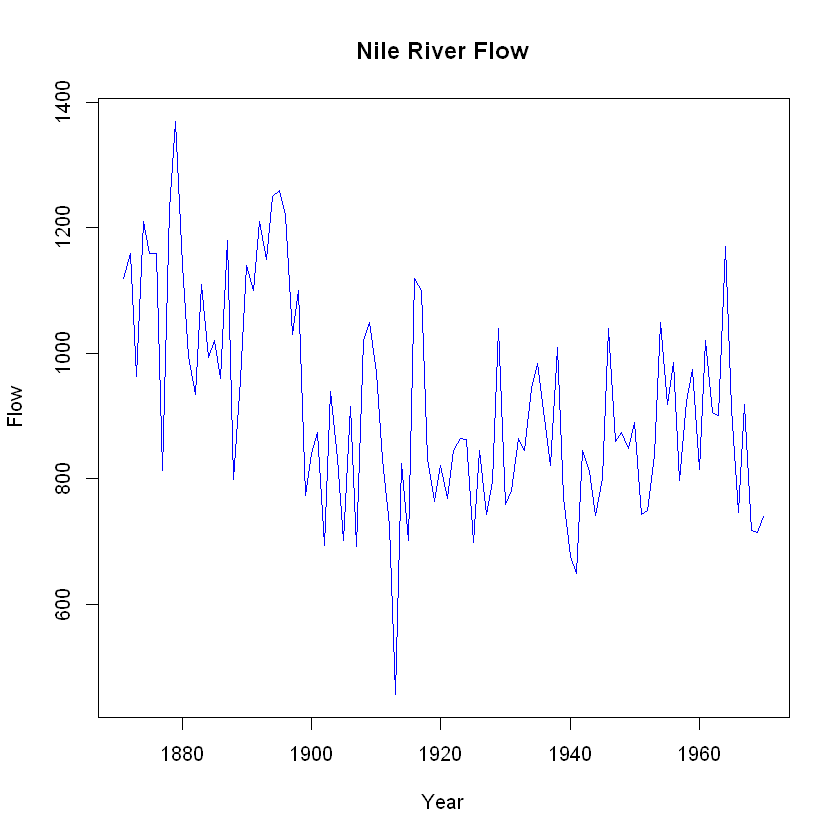

In [ ]:
# analyser tendance
plot(Nile,
     main = "Nile River Flow",
     ylab = "Flow",
     xlab = "Year",
     col = "blue",
     type = "l")

On peut observer que le graphe du débit annuel du Nil présente une tendance à la baisse au fil du temps, avec des fluctuations saisonnières.

On peut regarder avec Dickey-Fuller test pvalue > 0.05 donc la série est non stationnaire. Soit il faut différencier cela implique d = 1.

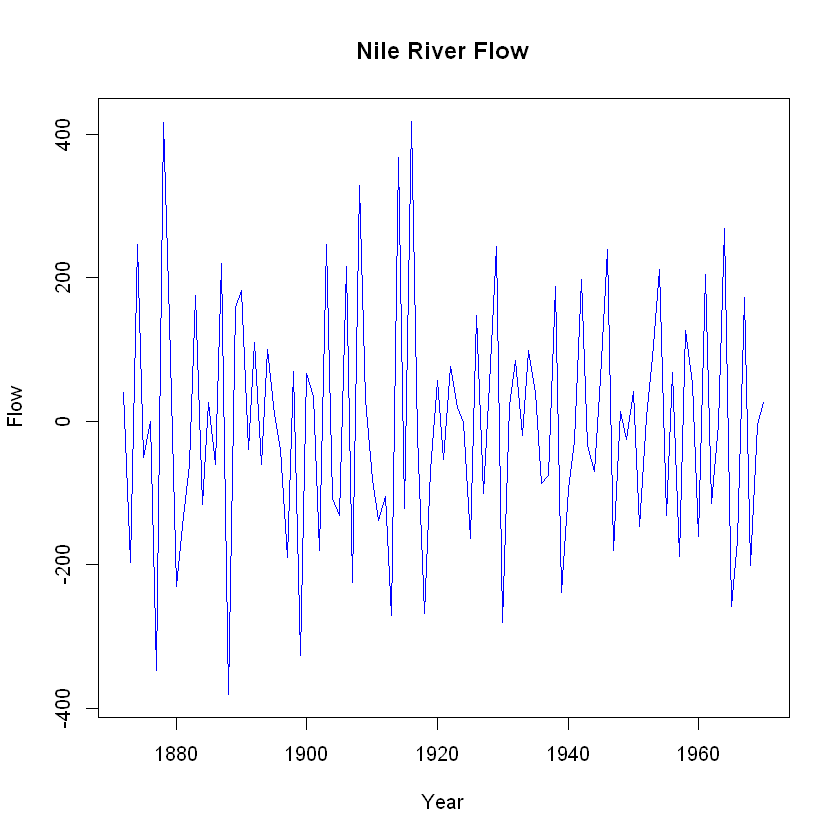

In [ ]:
dNile <- diff(Nile)
plot(dNile,
     main = "Nile River Flow",
     ylab = "Flow",
     xlab = "Year",
     col = "blue",
     type = "l")

Le test Dickey-Fuller est encore utiliser pour vérifier la stationnarité de la série temporelle après différenciation. 
On retrouve pvalue < 0.05 donc la série est stationnaire après différenciation.

D'ou on conclue d = 1.


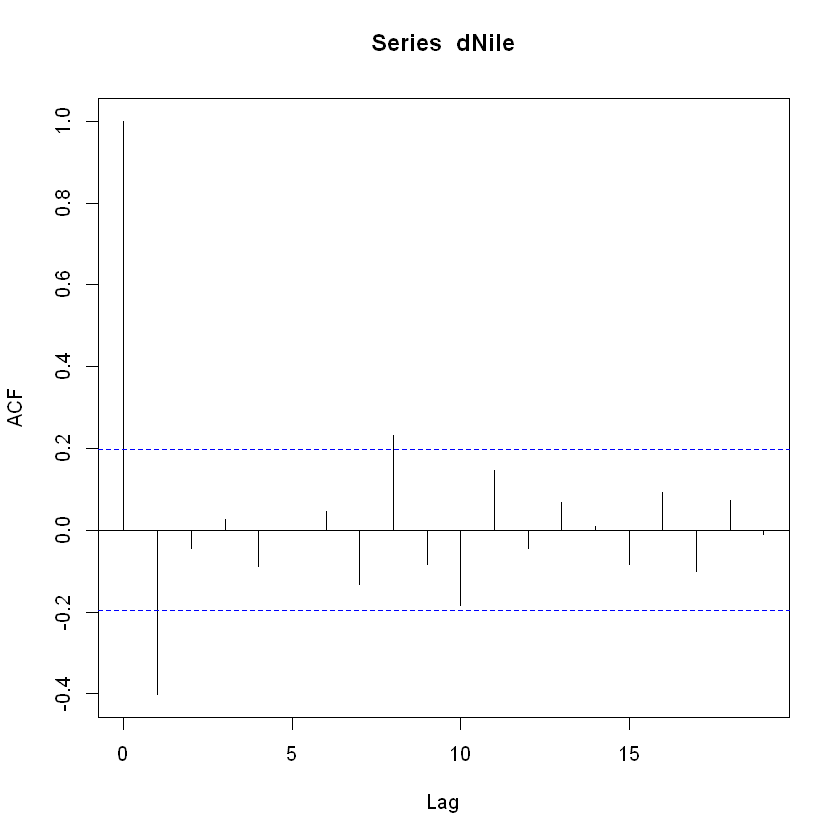

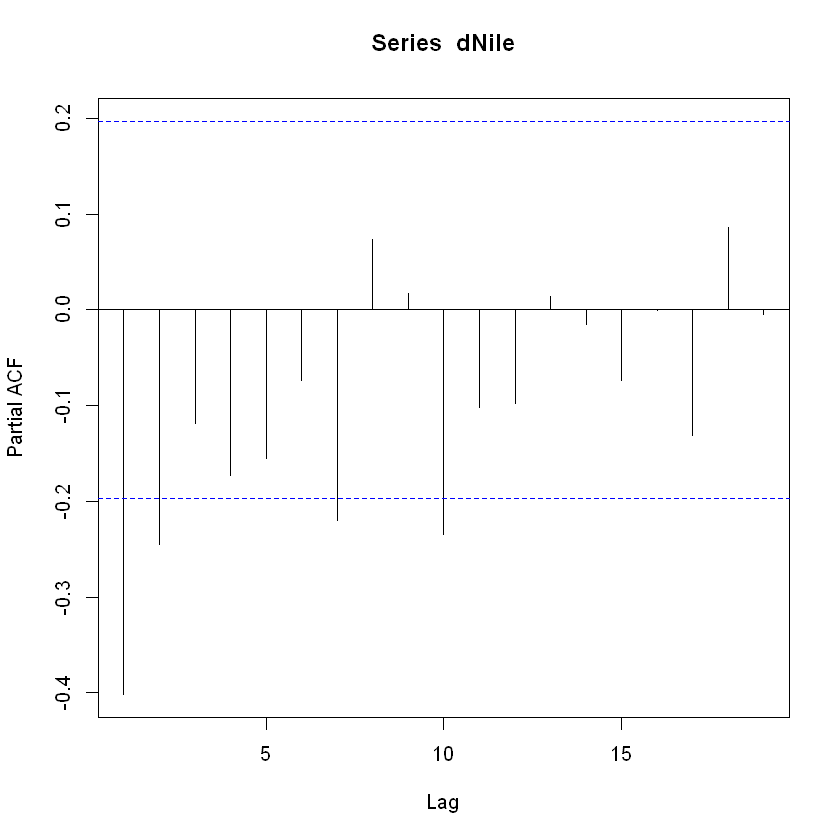

In [ ]:
acf(dNile)
pacf(dNile)

In [ ]:
install.packages("feasts")
install.packages("tsibble")

Installation du package dans 'C:/Users/flavi/AppData/Local/R/win-library/4.4'
(car 'lib' n'est pas spécifié)

installation des dépendances 'BH', 'distributional', 'ggdist', 'anytime', 'warp', 'fabletools', 'tsibble', 'slider', 'ggtime'





  Une version binaire est disponible mais la version du source est plus
  récente:
           binary source needs_compilation
fabletools  0.6.1  0.7.0             FALSE

le package 'BH' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'distributional' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'ggdist' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'anytime' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'warp' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'tsibble' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'slider' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'ggtime' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'feasts' a été décompressé et les sommes MD5 ont été vérifiées avec succés

Les packages binaires téléchargés sont dans
	C:\Us

installation du package source 'fabletools'


Installation du package dans 'C:/Users/flavi/AppData/Local/R/win-library/4.4'
(car 'lib' n'est pas spécifié)



le package 'tsibble' a été décompressé et les sommes MD5 ont été vérifiées avec succés

Les packages binaires téléchargés sont dans
	C:\Users\flavi\AppData\Local\Temp\RtmpEnGxuR\downloaded_packages


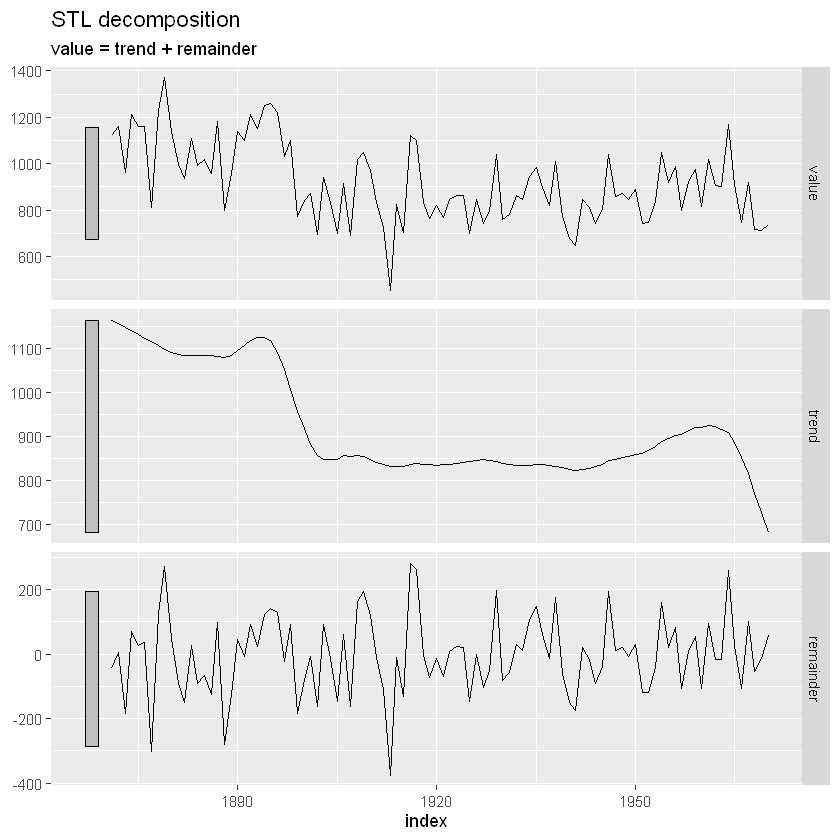

In [ ]:
library(feasts)
library(tsibble)

nile_ts <- as_tsibble(Nile)
nile_ts %>%
  model(STL(value ~ trend(window = 7))) %>%
  components() %>%
  autoplot()



## FLAVIO - ARIMA

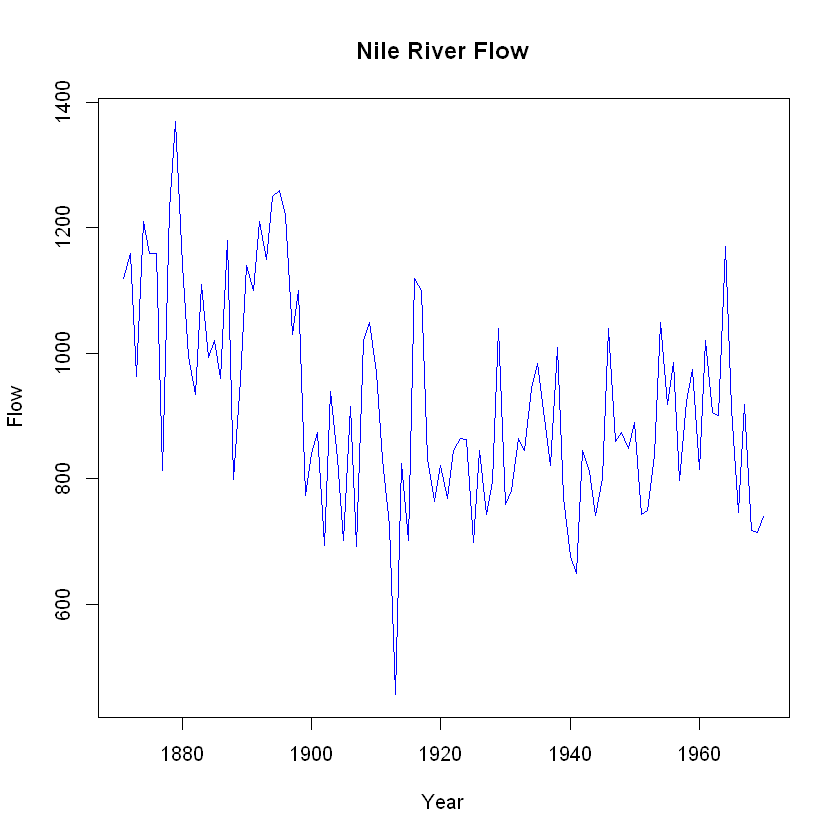

In [9]:
# Charger le dataset Nile
data(Nile)

# Afficher le graphique
plot(Nile,
     main = "Nile River Flow",
     ylab = "Flow",
     xlab = "Year",
     col = "blue",
     type = "l")

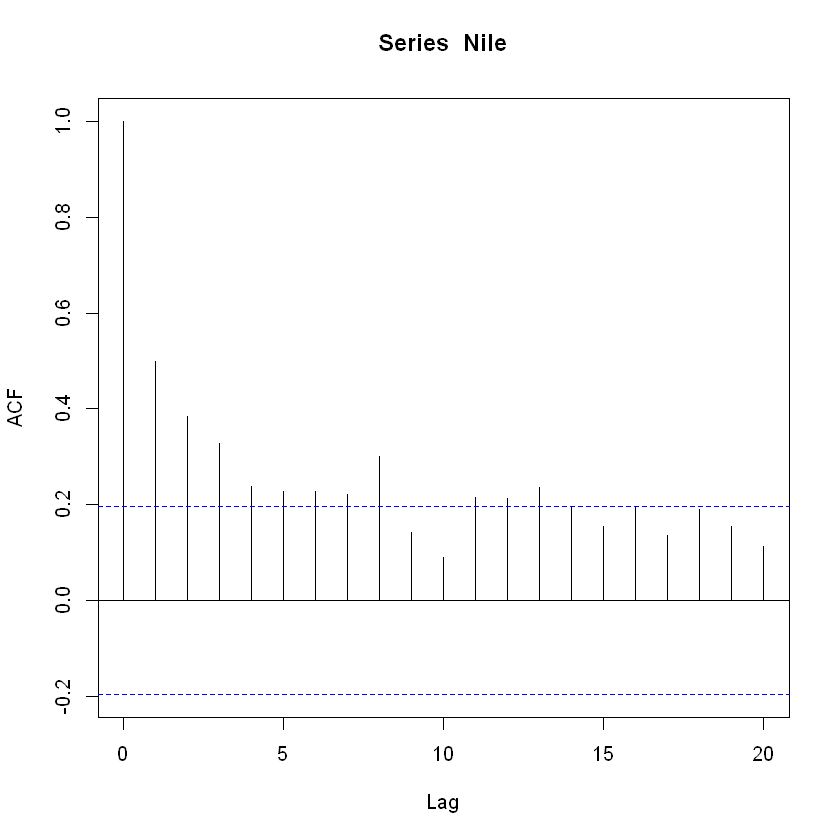

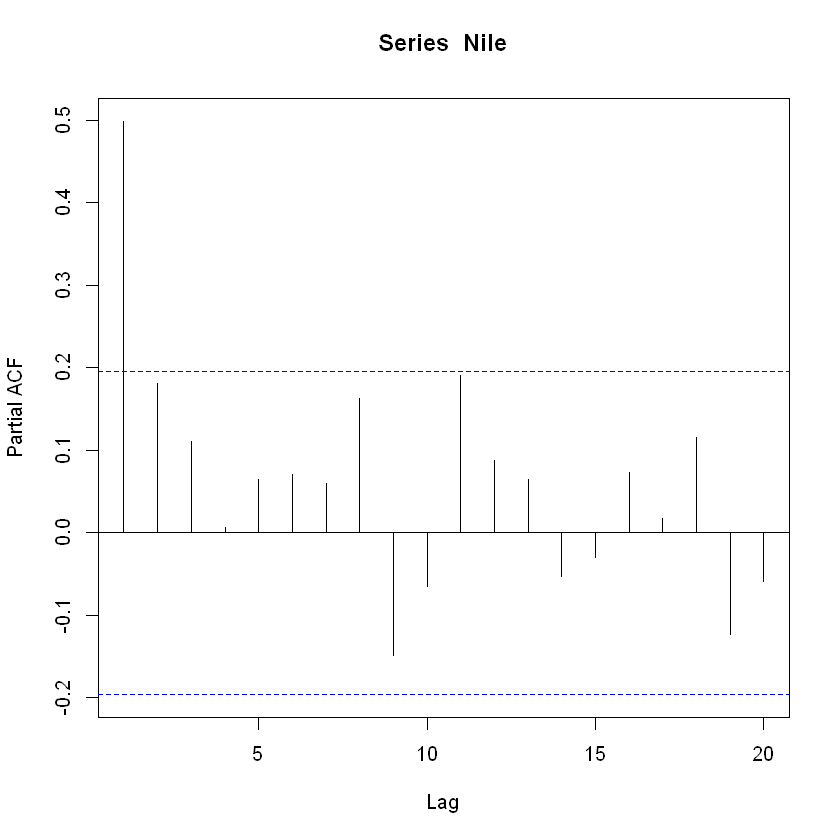

In [10]:
acf(Nile)
pacf(Nile)

In [ ]:
library(tseries)              

adf.test(Nile)


Warning message:
"le package 'tseries' est en cours d'utilisation et ne sera pas installé"



	Augmented Dickey-Fuller Test

data:  Nile
Dickey-Fuller = -3.3657, Lag order = 4, p-value = 0.0642
alternative hypothesis: stationary


On peut regarder que Dickey-Fuller donne un test pvalue > 0.05 donc la série est non stationnaire. Soit il faut différencier cela implique d = 1 pour Arima.
C-a-d que le résultat obtenu est extrême ou plus extrême que celui observé sous l’hypothèse nulle au seuil de 5%. Donc on rejette l’hypothèse nulle et on conclue que la série est stationnaire après différenciation.

In [ ]:
adf.test(dNile)

Warning message in adf.test(dNile):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  dNile
Dickey-Fuller = -6.5924, Lag order = 4, p-value = 0.01
alternative hypothesis: stationary


Ici pvalue < 0.05 donc la série est stationnaire après différenciation.

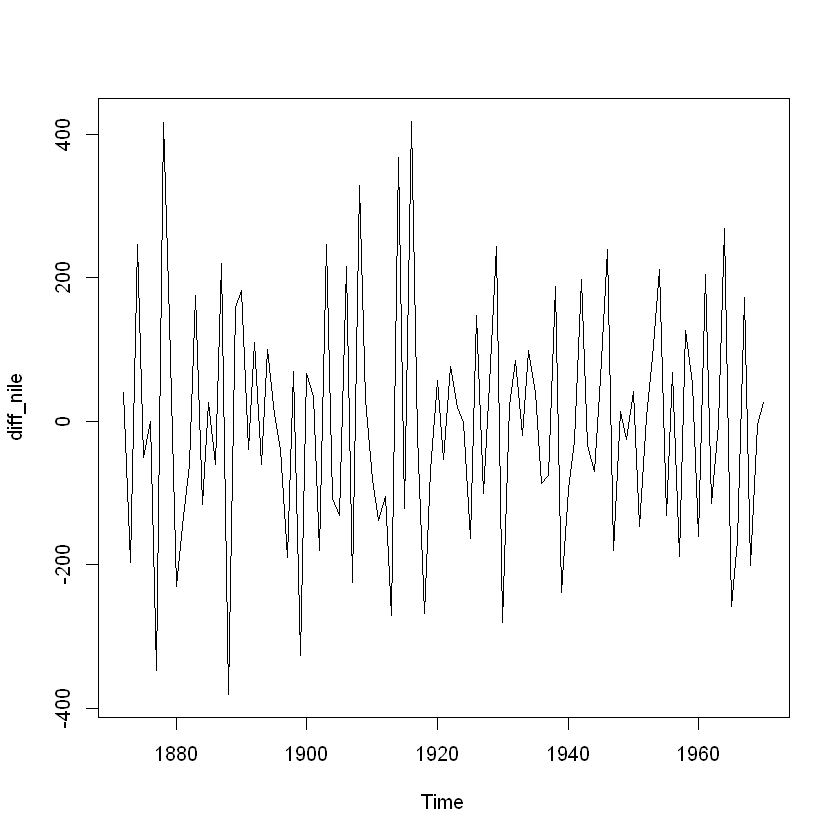

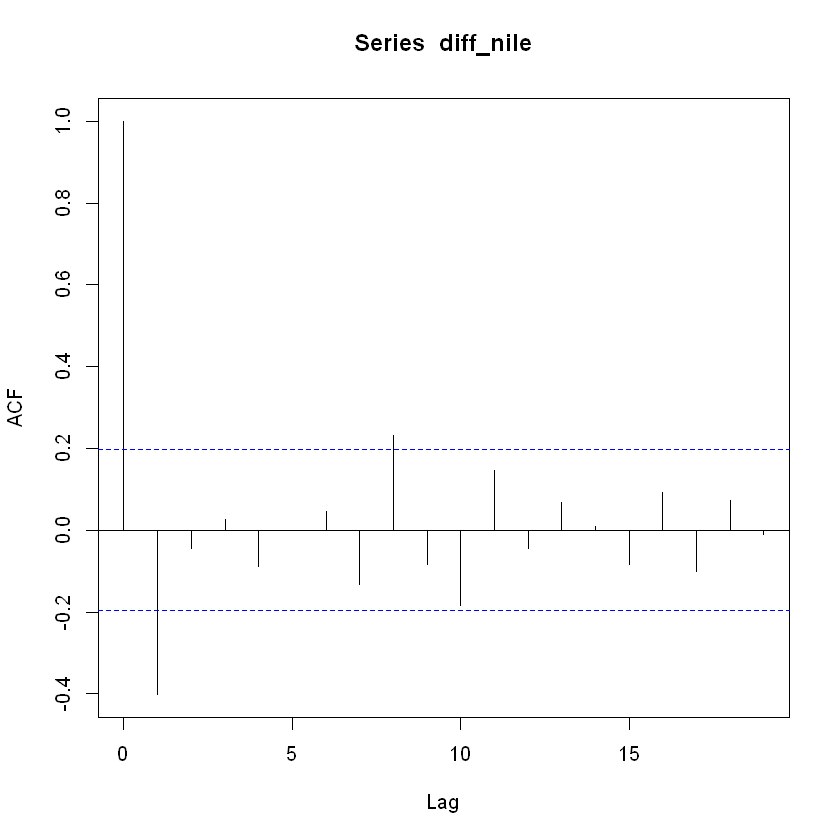

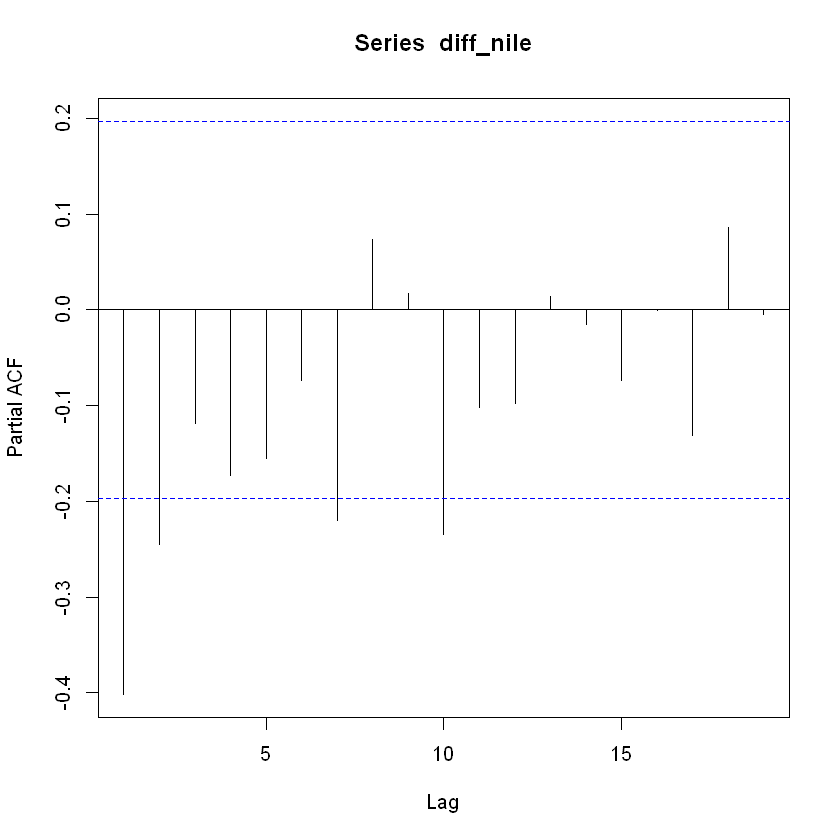

In [3]:
diff_nile <- diff(Nile)

plot(diff_nile)
acf(diff_nile)
pacf(diff_nile)

A partir de PACF on peut observer que lag 1 est beaucoup significatif et lag 2 un peu plus significatif comparé au lag 1 on peut conclure que p = 1 ou 2.


Cependant ACF montre que seul lag 1 est significatif, on peut conclure que q = 1.

In [4]:
p1 = 1
p2 = 2
d = 1
q = 1
m1 <- arima(Nile, order = c(p1, d, q))
m2 <- arima(Nile, order = c(p2, d, q))
m3 <- arima(Nile, order = c(6, 0, 7))
AIC(m1, m2, m3)



Warning message in AIC.default(m1, m2, m3):
"tous les modèles n'ont pas été ajustés sur le même nombre d'observations"


,df,AIC
,<dbl>,<dbl>
m1,3,1267.255
m2,4,1268.896
m3,15,1283.434


On peut observer que m1 < m2, donc le modèle ARIMA(1,1,1) est meilleur que ARIMA(2,1,1) selon le critère AIC.

In [5]:
library(forecast)
auto.arima(Nile)

Warning message:
"le package 'forecast' a été compilé avec la version R 4.4.3"


Series: Nile 
ARIMA(1,1,1) 

Coefficients:
         ar1      ma1
      0.2544  -0.8741
s.e.  0.1194   0.0605

sigma^2 = 20177:  log likelihood = -630.63
AIC=1267.25   AICc=1267.51   BIC=1275.04

In [6]:
Box.test(m1$residuals, type = "Ljung-Box")



	Box-Ljung test

data:  m1$residuals
X-squared = 0.10739, df = 1, p-value = 0.7431


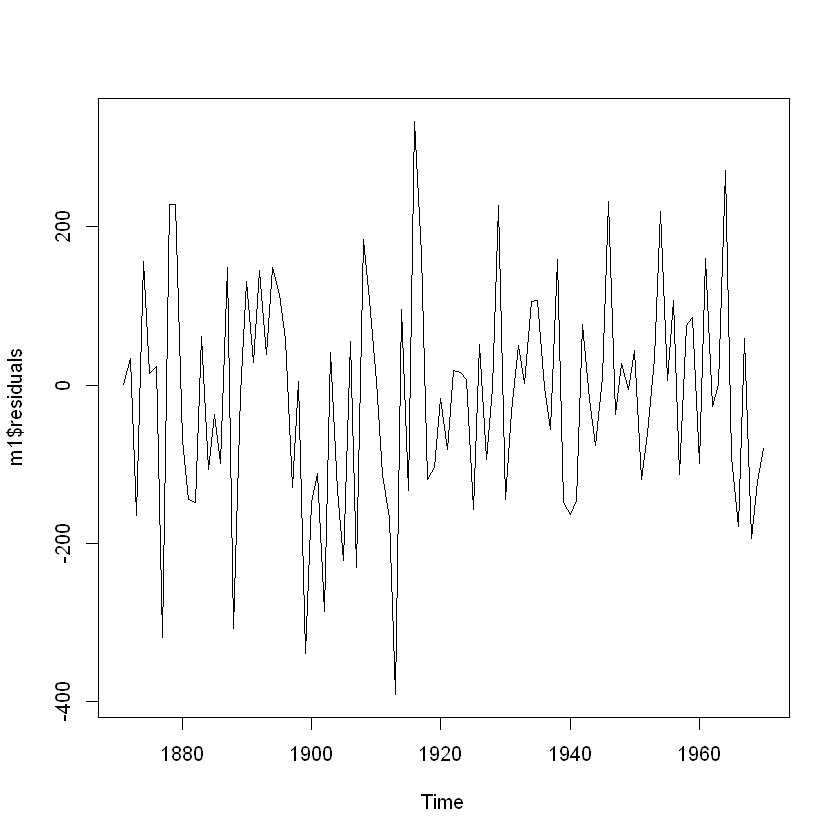

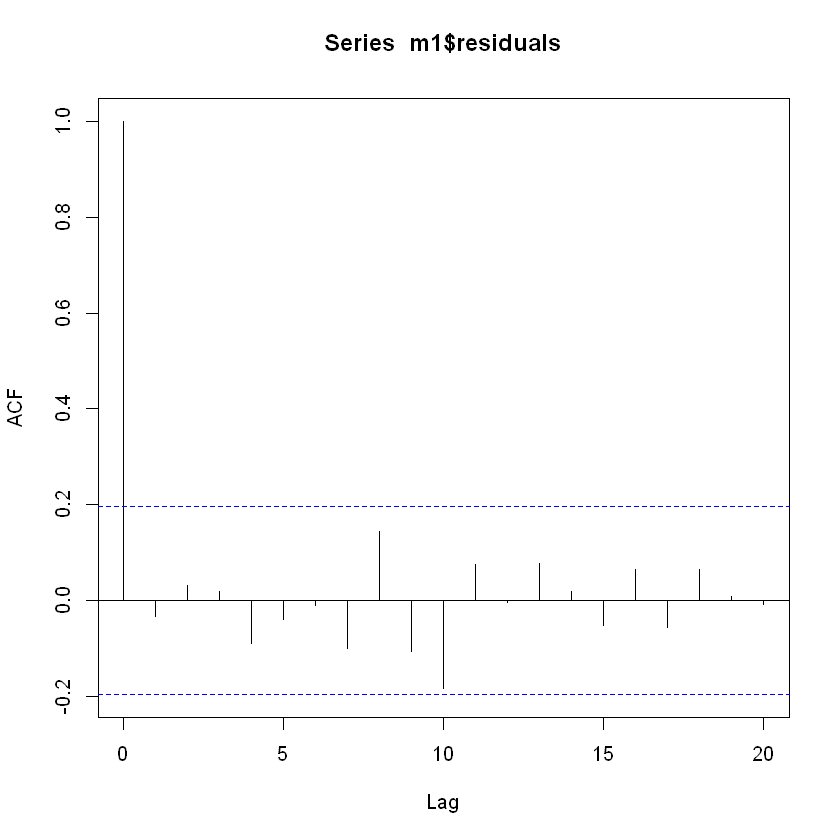

In [7]:
plot(m1$residuals)
acf(m1$residuals)


$pred
Time Series:
Start = 1971 
End = 2026 
Frequency = 1 
 [1] 816.1813 835.5596 840.4889 841.7428 842.0617 842.1429 842.1635 842.1687
 [9] 842.1701 842.1704 842.1705 842.1705 842.1705 842.1705 842.1705 842.1705
[17] 842.1705 842.1705 842.1705 842.1705 842.1705 842.1705 842.1705 842.1705
[25] 842.1705 842.1705 842.1705 842.1705 842.1705 842.1705 842.1705 842.1705
[33] 842.1705 842.1705 842.1705 842.1705 842.1705 842.1705 842.1705 842.1705
[41] 842.1705 842.1705 842.1705 842.1705 842.1705 842.1705 842.1705 842.1705
[49] 842.1705 842.1705 842.1705 842.1705 842.1705 842.1705 842.1705 842.1705

$se
Time Series:
Start = 1971 
End = 2026 
Frequency = 1 
 [1] 140.6033 150.4244 153.6455 155.7731 157.6453 159.4405 161.2020 162.9410
 [9] 164.6608 166.3626 168.0471 169.7149 171.3664 173.0022 174.6226 176.2282
[17] 177.8192 179.3962 180.9594 182.5092 184.0460 185.5700 187.0816 188.5811
[25] 190.0688 191.5449 193.0098 194.4636 195.9066 197.3390 198.7612 200.1732
[33] 201.5754 202.9678 204.3508 20

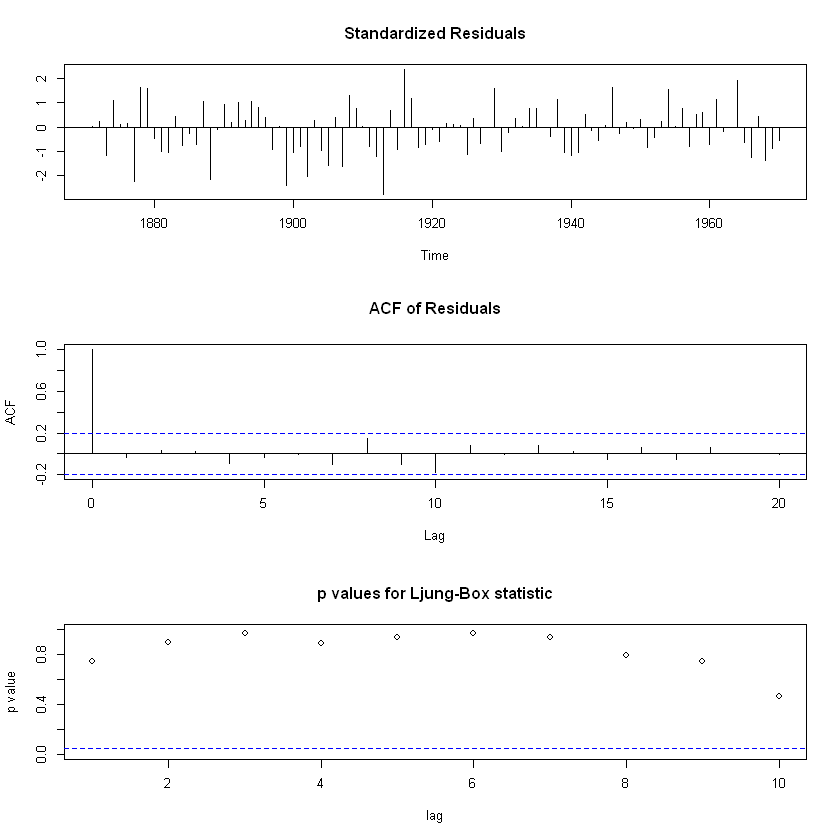

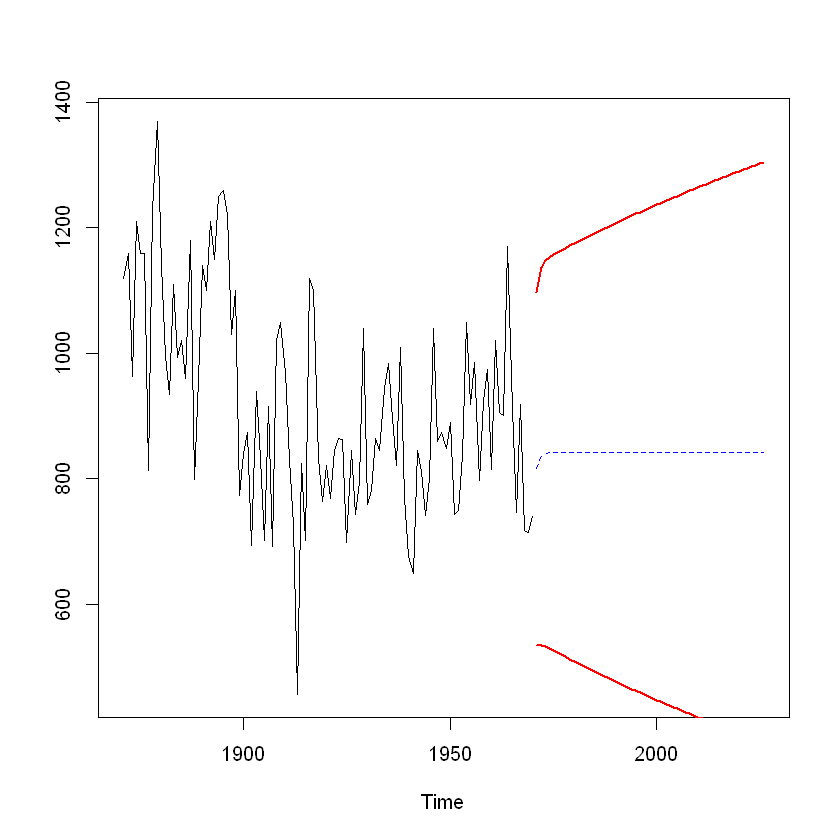

In [8]:

tsdiag(m1)
pred <- predict(m1,n.ahead = 30+26)
print(pred)

ts.plot(Nile, pred$pred, col =c("black","blue"), lty=c(1,2))
lines(pred$pred+ 2*pred$se, col = "red", lwd = 2)
lines(pred$pred- 2*pred$se, col = "red", lwd = 2)

In [20]:
train_X <- window(Nile, start = start(Nile), end = c(1871+79,1)) # train sur les 80 premières années

test_X <- window(Nile, start = c(1871+80,1), end = end(Nile)) # test sur les 20 dernières années


In [21]:
# Grid search for ARIMA parameters
p_values <- 0:3
d_values <- 0:3
q_values <- 0:3

best_score <- Inf
best_cfg = NULL

for (p in p_values) {
  for (d in d_values) {
    for (q in q_values) {
      order <- c(p, d, q)
      tryCatch({
        fit <- arima(train_X, order = order)

        n_ahead <- length(test_X)
        pred <- predict(fit, n.ahead = n_ahead)

        rmse <- sqrt(mean((test_X - pred$pred)^2))

        if (rmse < best_score) {
          best_score <- rmse
          best_cfg <- order
          cat(sprintf("ARIMA(%d,%d,%d) RMSE=%.4f\n", p, d, q, rmse))
        }
      }, error = function(e) {})
    }
  }
} 
cat(sprintf("Best ARIMA(%d,%d,%d) RMSE=%.4f\n", best_cfg[1], best_cfg[2], best_cfg[3], best_score))


ARIMA(0,0,0) RMSE=133.3132
ARIMA(0,0,1) RMSE=133.2104
ARIMA(0,0,2) RMSE=132.6503
ARIMA(0,0,3) RMSE=132.4787
ARIMA(0,1,0) RMSE=123.0624
ARIMA(0,1,1) RMSE=122.8044
ARIMA(0,2,1) RMSE=122.2813
ARIMA(1,1,0) RMSE=122.2032


Warning message in arima(train_X, order = order):
"problème de convergence possible : optim renvoie un code = 1"
Warning message in arima(train_X, order = order):
"problème de convergence possible : optim renvoie un code = 1"
Warning message in arima(train_X, order = order):
"problème de convergence possible : optim renvoie un code = 1"


Best ARIMA(1,1,0) RMSE=122.2032


,df,AIC
,<dbl>,<dbl>
m1,3,1267.255
m2,2,1281.480


$pred
Time Series:
Start = 1971 
End = 1980 
Frequency = 1 
 [1] 729.6641 733.7730 732.1396 732.7889 732.5308 732.6334 732.5926 732.6088
 [9] 732.6024 732.6049

$se
Time Series:
Start = 1971 
End = 1980 
Frequency = 1 
 [1] 153.2566 178.9211 213.5345 238.8087 263.2401 285.0025 305.4341 324.5008
 [9] 342.5383 359.6608



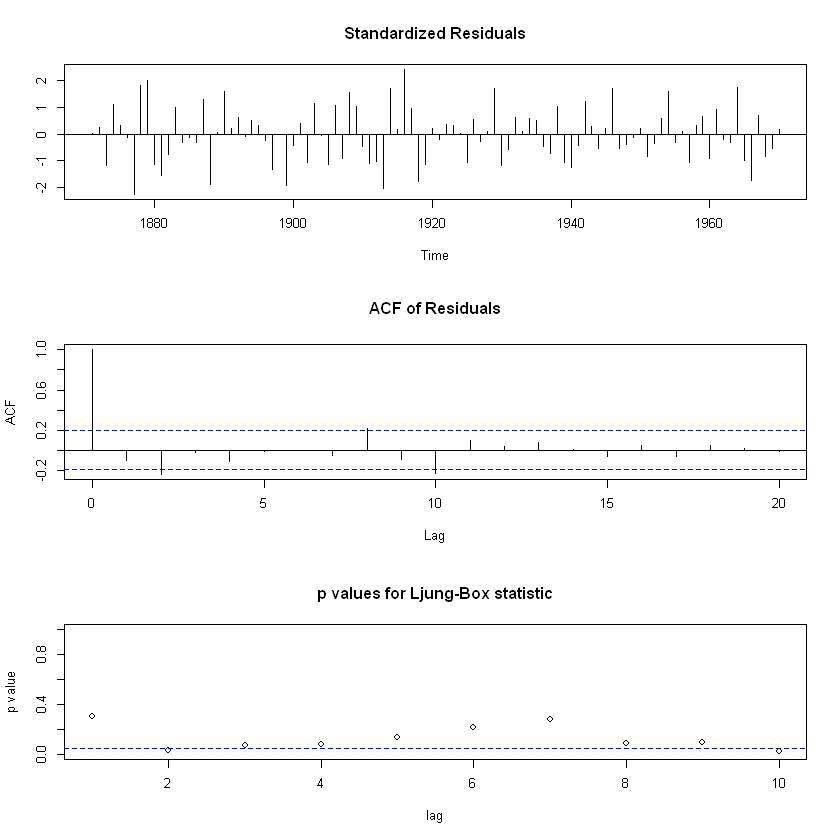

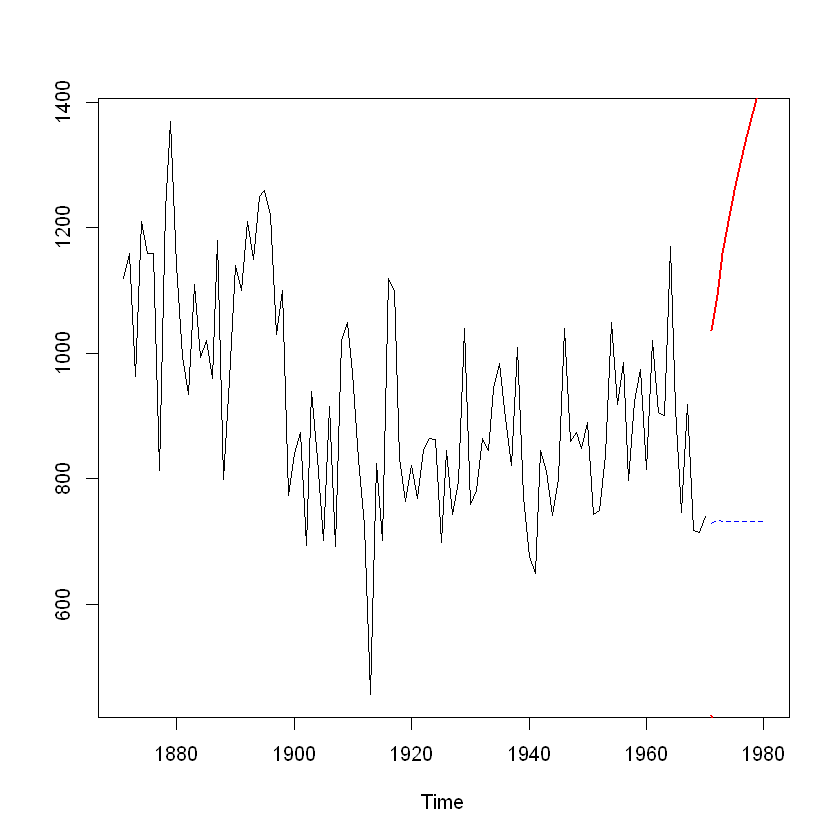

In [22]:

m2 <- arima(Nile, order = c(1, 1, 0))

AIC(m1,m2)

tsdiag(m2)
pred <- predict(m2,n.ahead = 10)
print(pred)

ts.plot(Nile, pred$pred, col =c("black","blue"), lty=c(1,2))
lines(pred$pred+ 2*pred$se, col = "red", lwd = 2)
lines(pred$pred- 2*pred$se, col = "red", lwd = 2)